In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import numpy.random as rd
from fractions import *
import scipy as sp
from functools import *
from IPython.display import display, Math
from scipy.integrate import odeint
import timeit
from tensorflow.keras.models import load_model
import h5py 

2025-02-20 13:26:12.819567: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-20 13:26:12.840883: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-20 13:26:12.847782: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-20 13:26:12.860720: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-20 13:26:15.004923: W tensorflow/compiler/tf2

In [3]:
# Condition 
mo = 3
c =  1.0
n =  1
N =  1000
n_cross = 2 
a0 = 1.0
sa = 0.1 
b0 =  1.0
sb =  0.1
s1 =  0.1
s2 = 1.5
phi_range = np.pi  
phidotin = 0.0
ain = 0.00000001
afi = 1.0
#ain = 0.001
rhocrit = 3.0 
rho_m0 = 0.81 
rho_r0 = 0.00027138 
rho_l0 = 2.19
rhol = rho_l0
mpl = 2.435e27
 
t_in = 4.42e-5
# t_in = 0.0
t_fi = 1
t = np.linspace(t_in, t_fi, N)

[312.5]


<IPython.core.display.Math object>

5.0 0.0 312.5 1e-08


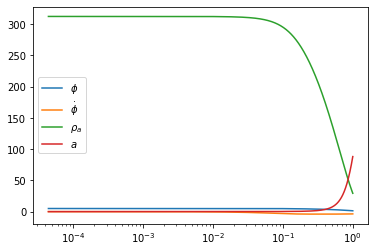

[5.]


In [4]:
def diag(mo,c,n,a0,b0,sa,sb,s1,s2,phi_range,phidotin):
	if mo == 3:

        ######################################
		####          Kahler              ####
		######################################

		k = (a0/np.random.uniform(s1,s2,(n,n))) #random matrix k from log normal distribution
		kT = k.transpose() # transpose of random matrix k
		k2 = np.dot(k,kT)  # Construction of symmeterised Kahler matric for real axion fields
		ev,pT = np.linalg.eigh(k2) # calculation of eigen values and eigen vectors
		fef = np.sqrt(ev)
		p = pT.transpose() # tranpose of rotational matrix constructed of eigen vectors
		kD = reduce(np.dot, [p, k2, pT]) #diagonalisation of Kahler metric
		kD[kD < 1*10**-13] = 0 # removal of computational error terms in off diagonal elements
		kDr = np.zeros((n, n))#creation of empty 3x3 matrix
		np.fill_diagonal(kDr, (1/((2**0.5)*np.sqrt(ev))))# matrix for absolving eigen values of kahler metric into axion fields
		#kDr[kDr > 1*10**23] = 0 # remove computational errors in reciprocal matrix
		kDrT = kDr.transpose() # trasnpose of kDr matrix

		######################################
		####            Mass              ####
		######################################

		m = (np.random.uniform(np.log(b0)-sb,np.log(b0)+sb,(n,n))) #random matrix m from log normal distribution
		mm = np.exp(-m)
		mT = mm.transpose() # transpose of random matrix m
		m2 = np.dot(mm,mT) # symmeterised mass matrix from real axion fields
		mn = reduce(np.dot, [pT,kDrT, m2, kDr,p]) # correct mass matrix caclulation
		ma_array,mv = np.linalg.eigh(mn) # reout of masses from eigenvalues of mn


	phiin_array = rd.uniform(-phi_range,phi_range,n)

	for i in range (0,n):
		phiin_array[i] = phiin_array[i]*fef[i]
	phiin_array=np.dot(mv,phiin_array)

	phidotin_array = [phidotin]*n #### array of phidotin where all are set equal to zero

	####################################################################
	####################################################################

		
	return ma_array,fef,phiin_array,phidotin_array

def rhoinitial(phidotin_array,phiin_array,ma_array,n):
	rhoin_array=[]
	for i in range(n):	
		rhoin_array.append( 0.5*phidotin_array[i]**2 + 0.5*(ma_array[i]**2)*phiin_array[i]**2 )
	return rhoin_array
	
###################################################################	

###################################################################
####                    Initial y array                        ####
###################################################################
	
def yinitial(n,phiin_array,phidotin_array,rhoin_array,ain):
	y0=[]
	for i in range(n):
		y0.append(phiin_array[i])
		y0.append(phidotin_array[i])
		y0.append(rhoin_array[i])
	y0.append(ain)
#	print(y0)
	return y0	

def deriv_rho(y,t,n,ma_array,rho_m0,rho_r0,rhol): 
	func=[]
	rho_ax=sum(y[:-1])
	for i in range(n):
		if np.sqrt(3)*np.sqrt(rho_ax + rho_m0/y[-1]**3 + rho_r0/y[-1]**4 + rhol) > 2*(ma_array[i]):
			func.append((-3/np.sqrt(3)*np.sqrt(rho_ax + rho_m0/y[-1]**3 + rho_r0/y[-1]**4 + rhol)*(1-1)*(y[i])))
		else:
			func.append((-3/np.sqrt(3)*np.sqrt(rho_ax + rho_m0/y[-1]**3 + rho_r0/y[-1]**4 + rhol)*(y[i])))	
	func.append((1/np.sqrt(3)*np.sqrt(rho_ax*y[-1]**2 + rho_m0/y[-1] + rho_r0/y[-1]**2 + rhol*y[-1]**2)))
	return func



def deriv_wfromphi(y, t, n, n_cross, ma_array, rho_m0, rho_r0, rhol):
#def deriv_wfromphi(y, ma_array):
#
    crossing_index = [0]*n
    func = []
    rho_ax = sum(y[2::3])  # ใช้ y แทน y ในการเข้าถึงค่าตัวแปร
#
    for i in range(n):
        if (crossing_index[i] % 2 == 0 and ma_array[i] * y[3*i] * y[3*i] < y[3*i+1] * y[3*i+1] and y[3*i+1] > 0) or \
           (crossing_index[i] % 2 == 1 and ma_array[i] * y[3*i] * y[3*i] > y[3*i+1] * y[3*i+1] and y[3*i+1] < 0):
            crossing_index[i] += 1
        
        func.append(y[3*i+1])  
        if crossing_index[i] < n_cross:
            func.append((-np.sqrt(3) * (np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol)) * y[3*i+1] - (ma_array[i]**2) * y[3*i]))
        else:
            func.append(-np.sqrt(3) * (np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol)) * y[3*i+1])
        
        if crossing_index[i] < n_cross:
            func.append(-3 / np.sqrt(3) * np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol) * y[3*i+1]**2)
        else:
            func.append(-3 / np.sqrt(3) * np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol) * y[3*i+2])

    func.append((1 / np.sqrt(3) * np.sqrt(rho_ax * (y[-1])**2 + rho_m0 / y[-1] + rho_r0 / y[-1]**2 + rhol * (y[-1])**2)))

#     print(crossing_index)

    return func

def eq(y,t):
    return deriv_wfromphi(y,t,n,n_cross,ma_array,rho_m0,rho_r0,rhol)

ma_array, fef, phiin_array, phidotin_array = diag(mo, c, n, a0, b0, sa, sb, s1, s2, phi_range, phidotin)
ma0 = 5.0
ma_array = np.array([ma0])
ma = ma_array
phiin_array = np.array([5.0])
rhoin_array = rhoinitial(phidotin_array, phiin_array, ma_array, n)
y0 = yinitial(n, phiin_array, phidotin_array, rhoin_array, ain)
# print(y0)
print(rhoin_array)
phi_in,dphi_in,rho_in,a_in=y0
# phi_in = 5.0
display(Math(r'$ \phi_0, \dot{\phi_0}, \rho_0, a_0 $'))
print(phi_in,dphi_in,rho_in,a_in)


t = np.linspace(t_in,t_fi,N)
y = odeint(eq,y0,t,mxstep=int(1e9))

# set phi_0 = 0
# y[:,0] = 0.0

uuut = t 
uuuy = y
# print(y)
#print('uuuy')
# print(uuuy[:,0])
plt.plot(uuut,uuuy[:,0],label = r'$\phi$')
plt.plot(uuut,uuuy[:,1],label = r'$\dot{\phi}$')
plt.plot(uuut,uuuy[:,2],label = r'$\rho_{a}$')
plt.plot(uuut,uuuy[:,3],label = r'$a$')
# plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()
print(ma_array)
# print(rhol)

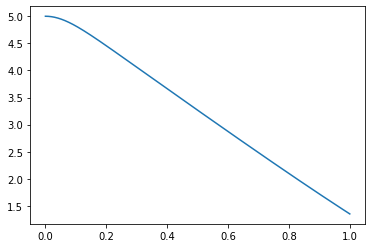

In [98]:
plt.plot(uuut,uuuy[:,0],label = r'$\phi$')


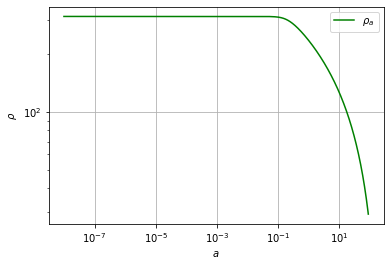

In [99]:
rhoa01 = y[:,2]
rhoa_0 = y[:,2].astype(np.float32)
pressure = (-0.5*ma_array[:]**2*y[:,0][:]**2 + 0.5*y[:,1][:]**2)
w = pressure/rhoa01
rhom01 = rho_m0/y[:,-1][:]**3
rhor01 = rho_r0/y[:,-1][:]**4
rhol01 = np.array(rhol)
rhom = np.array(rhom01)
rhol = np.array(rhol01)
rhor = np.array(rhor01)
rhoa = np.array(rhoa01)
rhosum = rhom+rhol+rhor+rhoa
H = (1/np.sqrt(3))*np.sqrt(rhosum[0:1000])
z = 1/y[:,-1][:] - 1

# plt.plot(y[:,-1][:],rhom,label=r'$\rho_m$',color='red')
plt.plot(y[:,-1][:],rhoa,label=r'$\rho_a$',color='green')
# plt.plot(y[:,-1][:],rhor,label=r'$\rho_r$',color='blue')
# plt.plot(y[:,-1][:],rhosum,label=r'$\rho_{sum}$',color='black')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('$a$')
plt.ylabel(r'$\rho $');
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [6]:
def log10(x):
#     return tf.math.log(x) / tf.math.log(tf.constant([[10.0]], dtype=tf.float32))
    return tf.math.log(x) / tf.math.log(tf.constant([[10.0]]))

ln10 = tf.math.log(tf.constant([[10.0]]))

t_tensor = tf.convert_to_tensor(np.linspace(t_in, t_fi, N).reshape(-1, 1), dtype=tf.float32)
T = log10(t_tensor)
# Ra = log10(rhoa_0)
# Rm = log10(rho_m0)
# Rr = log10(rho_r0)
# Rl = log10(rho_l0)
# M = log10(ma0)
# print(Ra,Rm,Rr,Rl,M)
# print(t_tensor,T)
print(ln10)

tf.Tensor([[2.3025851]], shape=(1, 1), dtype=float32)


2025-02-17 14:01:38.211148: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-02-17 14:01:38.211175: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:135] retrieving CUDA diagnostic information for host: weerachai
2025-02-17 14:01:38.211181: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:142] hostname: weerachai
2025-02-17 14:01:38.211297: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:166] libcuda reported version is: 560.35.3
2025-02-17 14:01:38.211318: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] kernel reported version is: NOT_FOUND: could not find kernel module information in driver version file contents: "NVRM version: NVIDIA UNIX Open Kernel Module for x86_64  560.35.03  Release Build  (dvs-builder@U16-I1-N07-12-3)  Fri Aug 16 21:42:42 UTC 2024
GCC version:  gcc version 12.3.0 (Ubuntu 12.3.0-1ubuntu1~22.04) 
"


In [69]:

NoN = 3 # Number output of NN

class SinActv(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SinActv, self).__init__(**kwargs)

    def call(self, inputs):
        return tf.math.sin(inputs)

# @tf.keras.saving.register_keras_serializable()
@tf.keras.utils.register_keras_serializable()
class NN(tf.keras.Model):
    def __init__(self):
        super(NN, self).__init__()
        self.hidden_layer_1 = tf.keras.layers.Dense(units = 256, activation='sigmoid')
#         self.hidden_layer_2 = tf.keras.layers.Dense(units = 256, activation='sigmoid')
#         self.hidden_layer_3 = tf.keras.layers.Dense(units = 256, activation='sigmoid')
#         self.hidden_layer_4 = tf.keras.layers.Dense(units = 256, activation='sigmoid')
#         self.hidden_layer_5 = tf.keras.layers.Dense(units = 256, activation='sigmoid')
#         self.hidden_layer_6 = tf.keras.layers.Dense(units = 256, activation='sigmoid')
        self.output_layer = tf.keras.layers.Dense(units = NoN, activation='sigmoid')  
        
    def call(self, x):
        x = self.hidden_layer_1(x)
#         x = self.hidden_layer_2(x)
#         x = self.hidden_layer_3(x)
#         x = self.hidden_layer_4(x)
#         x = self.hidden_layer_5(x)
#         x = self.hidden_layer_6(x)
        return self.output_layer(x)  
    


In [102]:
P0 = phi_in.astype(np.float32)
# P0 = log10(phi_in.astype(np.float32))

R0 = 0.5*ma**2*P0**2
print(ma)

[5.]


# Version 2.1
# EOM

P0 = phi_in.astype(np.float32)
# P0 = log10(phi_in.astype(np.float32))

R0 = 0.5*ma**2*P0**2
    
model = NN()  
def func(T, model):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(T)
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(T)
            U = model(T)
            A, Pt, rho_at = tf.math.log(U[:,0:1]), 2*U[:,1:2]-1, U[:,2:3]#, U[:,3:4]
        
        dA = tape1.gradient(A, T)
        dP = tape1.gradient(Pt, T)
        dRa = tape1.gradient(rho_at, T)
    ddP = tape2.gradient(dP, T)
    del tape1
    del tape2
    
#     P0 = log10(phi_in.astype(np.float32))
#     R0 = 0.5*ma**2*P0**2
    
# derivative of a
#    print(a,da)
    Adot = (
    10**(A-T)*dA - 1/tf.sqrt(tf.constant([[3.0]]))*tf.sqrt(0.5*10**(2*A)*(dP)**2*(1/(ln10*10**T))**2 
    + 0.5*10**(2*A)*ma**2*Pt**2 + rho_m0*10**(-A) + rho_r0*10**(-2*A) + rhol*10**(2*A))
    )
    
# derivative of phi 
    Phidott = (
    1/ln10 * (10**(-2*T)/ln10*ddP - dP*10**(-2*T)) + tf.sqrt(tf.constant([[3.0]]))*
        (0.5*dP**2*(1/(ln10*10**T))**2
    + 0.5*ma**2*Pt**2 + rho_m0*10**(-3*A) + rho_r0*10**(-4*A) + rhol )*dP*(1/(ln10*10**T)) + ma**2*Pt
    )
    
# rho_a
    Rhodot = (
    dRa*(1/(ln10*10**T)) + tf.sqrt(tf.constant([[3.0]]))*tf.sqrt(0.5*dP**2*(1/(ln10*10**T))**2 
    + 0.5*ma**2*Pt**2 + rho_m0*10**(-3*A) + rho_r0*10**(-4*A) + rhol)*dP**2*(1/(ln10*10**T))**2
    )

#     print('Adot',Adot,'Phidott',Phidott,'Rhodot',Rhodot)
    loss_f1 = tf.reduce_mean(tf.square(Adot))
    loss_f2 = tf.reduce_mean(tf.square(Phidott))
#    loss_f3 = tf.reduce_mean(tf.square(dP*(1/(ln10*10**T)) - phidot))
    loss_f4 = tf.reduce_mean(tf.square(Rhodot))
    total_loss = loss_f1 + loss_f2 + loss_f4# + loss_f4
    return total_loss

t_0 = tf.constant([[t_fi]], dtype=tf.float32)  # จุดเริ่มต้น t=0
T_0 = log10(t_0)

# IC Loss
def initial_condition_loss(T_0,model):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(T_0)
        u_pred = model(T_0)
        u1_pred, u2_pred, rho_a = tf.math.log(u_pred[:, 0]), 2*u_pred[:, 1]-1, u_pred[:,2:3]#, u_pred[:,3:4] # u1=a,u2=phi
#     du2_pred = tape.gradient(u2_pred,T_0)
#     print(du2_pred ,'log10_0',log10(phidotin)) # ตัดออกไปก่อน
    # IC สำหรับ u1 และ u2
    ic_loss_u1 = tf.reduce_mean(tf.square(u1_pred - log10(ain)))  # a = u1(t=0) = 1e-8
    ic_loss_u2 = tf.reduce_mean(tf.square(u2_pred - 1))   # phi = u2(t=0) = 0
#     ic_loss_u2 = tf.reduce_mean(tf.square(P0*u2_pred - log10(phi_in.astype(np.float32))))   # phi = u2(t=0) = 0
#     ic_loss_du2 = tf.reduce_mean(tf.square(du2_pred - log10(phidotin))) # ตัดออกไปก่อน
#     print('u1',ic_loss_u1,'u2',ic_loss_u2,'du2',ic_loss_du2)
    return ic_loss_u1 + ic_loss_u2 #+ ic_loss_du2

# BC Loss
# def boundary_condition_loss(model):
#     t_final_tensor = tf.constant([[t_fi]], dtype=tf.float32)  # จุด t = t_final
#     T_final_tensor = log10(t_final_tensor)
#     u_pred = model(T_final_tensor)
#     u1_pred = u_pred[:, 0]

#     bc_loss_u1 = tf.reduce_mean(tf.square(u1_pred - log10(1.0)))  # u1(t=t_final) = 1
    
#     return bc_loss_u1


# loss function
def loss_fn(t,model):
    ode_loss = func(T, model)
    ic_loss = initial_condition_loss(T_0,model)
#     bc_loss = boundary_condition_loss(model)
    total_loss = ode_loss #+ ic_loss #+ bc_loss
#     print('ode',ode_loss,'ic',ic_loss,'bc',bc_loss)
    return total_loss


In [110]:
# Version 2.2
# EOM
model = NN()  
def func(T, model):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(T)
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(T)
            U = model(T)
            A, Pt, rho_at = tf.math.log(U[:,0:1]), 2*U[:,1:2]-1, U[:,2:3]#, U[:,3:4]
        
        dA = tape1.gradient(A, T)
        dP = tape1.gradient(Pt, T)
        dRa = tape1.gradient(rho_at, T)
    ddP = tape2.gradient(dP, T)
    del tape1
    del tape2
    
#     P0 = 
#     R0 = 0.5*ma**2*P0**2
# derivative of a
#    print(a,da)
    Adot = (
    10**(A-T)*dA - 1/tf.sqrt(tf.constant([[3.0]]))*tf.sqrt(0.5*10**(2*A)*(P0*dP)**2*(1/(ln10*10**T))**2 
    + 0.5*10**(2*A)*ma**2*P0**2*Pt**2 + rho_m0*10**(-A) + rho_r0*10**(-2*A) + rhol*10**(2*A))
    )
    
# derivative of phi 
    Phidott = (
    P0/ln10 * (10**(-2*T)/ln10*ddP - dP*10**(-2*T)) + tf.sqrt(tf.constant([[3.0]]))*
        (0.5*P0**2*dP**2*(1/(ln10*10**T))**2
    + 0.5*ma**2*P0**2*Pt**2 + rho_m0*10**(-3*A) + rho_r0*10**(-4*A) + rhol )*P0*dP*(1/(ln10*10**T)) + ma**2*Pt*P0
    )
    
# rho_a
    Rhodot = (
    R0*dRa*(1/(ln10*10**T)) + tf.sqrt(tf.constant([[3.0]]))*tf.sqrt(0.5*P0**2*dP**2*(1/(ln10*10**T))**2 
    + 0.5*ma**2*P0**2*Pt**2 + rho_m0*10**(-3*A) + rho_r0*10**(-4*A) + rhol)*P0**2*dP**2*(1/(ln10*10**T))**2
    )

#     print('Adot',Adot,'Phidott',Phidott,'Rhodot',Rhodot)
    loss_f1 = tf.reduce_mean(tf.square(Adot))
    loss_f2 = tf.reduce_mean(tf.square(Phidott))
#    loss_f3 = tf.reduce_mean(tf.square(dP*(1/(ln10*10**T)) - phidot))
    loss_f4 = tf.reduce_mean(tf.square(Rhodot))
    total_loss = loss_f1 + loss_f2 + loss_f4# + loss_f4
    return loss_f1 , loss_f2 , loss_f4
#     return total_loss

t_0 = tf.constant([[t_fi]], dtype=tf.float32)  # จุดเริ่มต้น t=0
T_0 = log10(t_0)

# IC Loss
def initial_condition_loss(T_0,model):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(T_0)
        u_pred = model(T_0)
        u1_pred, u2_pred, rho_a = tf.math.log(u_pred[:, 0]), 2*u_pred[:, 1]-1, u_pred[:,2:3]#, u_pred[:,3:4] # u1=a,u2=phi
#     du2_pred = tape.gradient(u2_pred,T_0)
#     print(du2_pred ,'log10_0',log10(phidotin)) # ตัดออกไปก่อน
    # IC สำหรับ u1 และ u2
    ic_loss_u1 = tf.reduce_mean(tf.square(u1_pred - log10(ain)))  # a = u1(t=0) = 1e-8
    ic_loss_u2 = tf.reduce_mean(tf.square(u2_pred - 1))   # phi = u2(t=0) = 0
#     ic_loss_u2 = tf.reduce_mean(tf.square(u2_pred - log10(phi_in.astype(np.float32))))   # phi = u2(t=0) = 0

#     ic_loss_du2 = tf.reduce_mean(tf.square(du2_pred - log10(phidotin))) # ตัดออกไปก่อน
#     print('u1',ic_loss_u1,'u2',ic_loss_u2,'du2',ic_loss_du2)
    return ic_loss_u1 + ic_loss_u2 #+ ic_loss_du2

# BC Loss
# def boundary_condition_loss(model):
#     t_final_tensor = tf.constant([[t_fi]], dtype=tf.float32)  # จุด t = t_final
#     T_final_tensor = log10(t_final_tensor)
#     u_pred = model(T_final_tensor)
#     u1_pred = u_pred[:, 0]

#     bc_loss_u1 = tf.reduce_mean(tf.square(u1_pred - log10(1.0)))  # u1(t=t_final) = 1
    
#     return bc_loss_u1


# loss function
def loss_fn(t,model):
    ode_loss = func(T, model)
    ic_loss = initial_condition_loss(T_0,model)
#     bc_loss = boundary_condition_loss(model)
    total_loss = ode_loss + ic_loss #+ bc_loss
#     print('ode',ode_loss,'ic',ic_loss,'bc',bc_loss)
    print(ode_loss)
    return total_loss
#     return ode_loss


In [111]:
# Version 1
# tf.no_gradient

model = NN()
# t_tensor = tf.convert_to_tensor(np.linspace(t_in, t_fi, N).reshape(-1, 1), dtype=tf.float32)
#t_tensor = tf.constant(np.linspace(t_in, t_fi, 100).reshape(-1, 1), dtype=tf.float32)
#x_train = tf.convert_to_tensor(np.random.rand(100, 2), dtype=tf.float32)
t0 = tf.constant([[t_in]], dtype=tf.float32)
print(t0)
epochs = 5000
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-2)
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        loss = loss_fn(T, model)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
#     print()    
    if epoch % 500 == 0:
        print(f'Epoch: {epoch}, Loss: {loss.numpy()}')

tf.no_gradient
        
    
# Results
u_pred = model(T).numpy()
t_data = np.linspace(t_in,t_fi,N).reshape(-1,1)
u1_pred, u2_pred, u3_pred = u_pred[:, 0], u_pred[:, 1], u_pred[:, 2]
print(epoch,loss.numpy())

tf.no_gradient

# print('u1',u1_pred,'u2', u2_pred,'u3', u3_pred,'u4', u4_pred)

# Plot results
plt.figure(dpi=150)
plt.plot(T, u1_pred, label=r'$A_{pinn}$',color ='r')
plt.plot(T, u2_pred, label=r'$\tilde{\phi}_{pinn}$',color ='b')
plt.plot(T, u3_pred, label=r'$\tilde{\rho}_{pinn}$',color ='g')
# plt.plot(T, u4_pred, label=r'$\rho_{pinn}$',color ='y')
# plt.plot(log10(uuut),log10(uuuy[:,3]),label = r'$a_{numer}$',linestyle='-.')
# plt.plot(log10(uuut),log10(uuuy[:,0]),label = r'$\phi_{numer}$',linestyle='-.')
# plt.plot(log10(uuut),log10(uuuy[:,1]),label = r'$\dot{\phi}_{numer}$',linestyle='-.')
# plt.plot(log10(uuut),log10(uuuy[:,2]),label = r'$\rho_{numer}$',linestyle='-.')
plt.xlabel('Time')
plt.ylabel('Solution')
#plt.ylim(0.9e-8,1.1e-8)
plt.legend()
plt.show()
# print(u1_pred[-1])

tf.Tensor([[4.42e-05]], shape=(1, 1), dtype=float32)
(<tf.Tensor: shape=(), dtype=float32, numpy=22.711542>, <tf.Tensor: shape=(), dtype=float32, numpy=39942820000000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=91503710000000.0>)
Epoch: 0, Loss: [8.4774124e+01 3.9942818e+13 9.1503708e+13]
(<tf.Tensor: shape=(), dtype=float32, numpy=21.950668>, <tf.Tensor: shape=(), dtype=float32, numpy=33253868000000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=76832270000000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=21.203236>, <tf.Tensor: shape=(), dtype=float32, numpy=27550270000000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=64248957000000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=20.47296>, <tf.Tensor: shape=(), dtype=float32, numpy=22726373000000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=53538697000000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=19.763418>, <tf.Tensor: shape=(), dtype=float32, numpy=18678177000000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=4448851

(<tf.Tensor: shape=(), dtype=float32, numpy=9.76666>, <tf.Tensor: shape=(), dtype=float32, numpy=48650502000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=314842320000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=9.736616>, <tf.Tensor: shape=(), dtype=float32, numpy=46062790000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=303906550000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=9.708294>, <tf.Tensor: shape=(), dtype=float32, numpy=43710726000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=293851800000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=9.681555>, <tf.Tensor: shape=(), dtype=float32, numpy=41566323000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=284581920000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=9.6562805>, <tf.Tensor: shape=(), dtype=float32, numpy=39605993000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=276015380000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=9.632334>, <tf.Tensor: shape=(), dtype=float32, numpy=37808140000.0>, <tf.Tensor: shap

(<tf.Tensor: shape=(), dtype=float32, numpy=9.080501>, <tf.Tensor: shape=(), dtype=float32, numpy=10135372000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=128020430000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=9.072756>, <tf.Tensor: shape=(), dtype=float32, numpy=9901531000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=126556080000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=9.065076>, <tf.Tensor: shape=(), dtype=float32, numpy=9673120000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=125115780000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=9.0574665>, <tf.Tensor: shape=(), dtype=float32, numpy=9450090000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=123699810000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=9.04992>, <tf.Tensor: shape=(), dtype=float32, numpy=9232110000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=122306130000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=9.04244>, <tf.Tensor: shape=(), dtype=float32, numpy=9019241000.0>, <tf.Tensor: shape=(), 

(<tf.Tensor: shape=(), dtype=float32, numpy=8.769013>, <tf.Tensor: shape=(), dtype=float32, numpy=3194497000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=77635530000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=8.763592>, <tf.Tensor: shape=(), dtype=float32, numpy=3114025500.0>, <tf.Tensor: shape=(), dtype=float32, numpy=76903380000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=8.758213>, <tf.Tensor: shape=(), dtype=float32, numpy=3035300400.0>, <tf.Tensor: shape=(), dtype=float32, numpy=76180600000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=8.752862>, <tf.Tensor: shape=(), dtype=float32, numpy=2958302000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=75467284000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=8.747553>, <tf.Tensor: shape=(), dtype=float32, numpy=2883020500.0>, <tf.Tensor: shape=(), dtype=float32, numpy=74763410000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=8.742279>, <tf.Tensor: shape=(), dtype=float32, numpy=2809392400.0>, <tf.Tensor: shape=(), dtype

(<tf.Tensor: shape=(), dtype=float32, numpy=8.545032>, <tf.Tensor: shape=(), dtype=float32, numpy=811625900.0>, <tf.Tensor: shape=(), dtype=float32, numpy=51078730000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=8.541049>, <tf.Tensor: shape=(), dtype=float32, numpy=785173100.0>, <tf.Tensor: shape=(), dtype=float32, numpy=50672140000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=8.537087>, <tf.Tensor: shape=(), dtype=float32, numpy=759346700.0>, <tf.Tensor: shape=(), dtype=float32, numpy=50269740000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=8.533153>, <tf.Tensor: shape=(), dtype=float32, numpy=734181760.0>, <tf.Tensor: shape=(), dtype=float32, numpy=49872167000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=8.529239>, <tf.Tensor: shape=(), dtype=float32, numpy=709637250.0>, <tf.Tensor: shape=(), dtype=float32, numpy=49478984000.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=8.525344>, <tf.Tensor: shape=(), dtype=float32, numpy=685685060.0>, <tf.Tensor: shape=(), dtype=float

...

(<tf.Tensor: shape=(), dtype=float32, numpy=6.957961>, <tf.Tensor: shape=(), dtype=float32, numpy=2161195500.0>, <tf.Tensor: shape=(), dtype=float32, numpy=345045100.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.957307>, <tf.Tensor: shape=(), dtype=float32, numpy=2160666000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=344197400.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.9566503>, <tf.Tensor: shape=(), dtype=float32, numpy=2160136200.0>, <tf.Tensor: shape=(), dtype=float32, numpy=343349950.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.955995>, <tf.Tensor: shape=(), dtype=float32, numpy=2159608300.0>, <tf.Tensor: shape=(), dtype=float32, numpy=342509820.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.9553394>, <tf.Tensor: shape=(), dtype=float32, numpy=2159076600.0>, <tf.Tensor: shape=(), dtype=float32, numpy=341666940.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.954683>, <tf.Tensor: shape=(), dtype=float32, numpy=2158544000.0>, <tf.Tensor: shape=(), dtype=float32

(<tf.Tensor: shape=(), dtype=float32, numpy=6.923662>, <tf.Tensor: shape=(), dtype=float32, numpy=2132212900.0>, <tf.Tensor: shape=(), dtype=float32, numpy=302999400.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.922999>, <tf.Tensor: shape=(), dtype=float32, numpy=2131621600.0>, <tf.Tensor: shape=(), dtype=float32, numpy=302225570.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.922336>, <tf.Tensor: shape=(), dtype=float32, numpy=2131036000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=301460930.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.9216714>, <tf.Tensor: shape=(), dtype=float32, numpy=2130443900.0>, <tf.Tensor: shape=(), dtype=float32, numpy=300692300.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.9210086>, <tf.Tensor: shape=(), dtype=float32, numpy=2129855400.0>, <tf.Tensor: shape=(), dtype=float32, numpy=299930620.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.9203444>, <tf.Tensor: shape=(), dtype=float32, numpy=2129259900.0>, <tf.Tensor: shape=(), dtype=float3

(<tf.Tensor: shape=(), dtype=float32, numpy=6.8903008>, <tf.Tensor: shape=(), dtype=float32, numpy=2101328400.0>, <tf.Tensor: shape=(), dtype=float32, numpy=266153740.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.8896294>, <tf.Tensor: shape=(), dtype=float32, numpy=2100681200.0>, <tf.Tensor: shape=(), dtype=float32, numpy=265451780.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.888958>, <tf.Tensor: shape=(), dtype=float32, numpy=2100030800.0>, <tf.Tensor: shape=(), dtype=float32, numpy=264748700.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.888287>, <tf.Tensor: shape=(), dtype=float32, numpy=2099383600.0>, <tf.Tensor: shape=(), dtype=float32, numpy=264051790.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.887615>, <tf.Tensor: shape=(), dtype=float32, numpy=2098730100.0>, <tf.Tensor: shape=(), dtype=float32, numpy=263351380.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.8869433>, <tf.Tensor: shape=(), dtype=float32, numpy=2098076000.0>, <tf.Tensor: shape=(), dtype=float3

(<tf.Tensor: shape=(), dtype=float32, numpy=6.8579493>, <tf.Tensor: shape=(), dtype=float32, numpy=2068854400.0>, <tf.Tensor: shape=(), dtype=float32, numpy=233861950.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.8572726>, <tf.Tensor: shape=(), dtype=float32, numpy=2068150000.0>, <tf.Tensor: shape=(), dtype=float32, numpy=233221340.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.8565955>, <tf.Tensor: shape=(), dtype=float32, numpy=2067444900.0>, <tf.Tensor: shape=(), dtype=float32, numpy=232582860.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.8559175>, <tf.Tensor: shape=(), dtype=float32, numpy=2066735500.0>, <tf.Tensor: shape=(), dtype=float32, numpy=231942400.0>)
(<tf.Tensor: shape=(), dtype=float32, numpy=6.8552403>, <tf.Tensor: shape=(), dtype=float32, numpy=2066023200.0>, <tf.Tensor: shape=(), dtype=float32, numpy=231302220.0>)


KeyboardInterrupt: 

4999 140428260.0


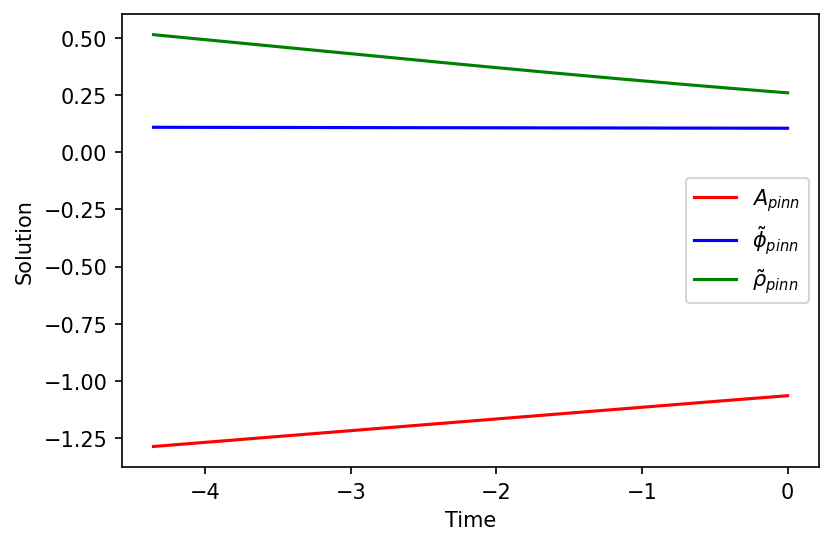

In [107]:
# Results
u_pred = model(T).numpy()
t_data = np.linspace(t_in,t_fi,N).reshape(-1,1)
u1_pred, u2_pred, u3_pred = tf.math.log(u_pred[:, 0]), 2*u_pred[:, 1]-1, u_pred[:, 2]
print(epoch,loss.numpy())

tf.no_gradient

# print('u1',u1_pred,'u2', u2_pred,'u3', u3_pred,'u4', u4_pred)

# Plot results
plt.figure(dpi=150)
plt.plot(T, u1_pred, label=r'$A_{pinn}$',color ='r')
plt.plot(T, u2_pred, label=r'$\tilde{\phi}_{pinn}$',color ='b')
plt.plot(T, u3_pred, label=r'$\tilde{\rho}_{pinn}$',color ='g')
# plt.plot(T, u4_pred, label=r'$\rho_{pinn}$',color ='y')
# plt.plot(log10(uuut),log10(uuuy[:,3]),label = r'$a_{numer}$',linestyle='-.')
# plt.plot(log10(uuut),log10(uuuy[:,0]),label = r'$\phi_{numer}$',linestyle='-.')
# plt.plot(log10(uuut),log10(uuuy[:,1]),label = r'$\dot{\phi}_{numer}$',linestyle='-.')
# plt.plot(log10(uuut),log10(uuuy[:,2]),label = r'$\rho_{numer}$',linestyle='-.')
plt.xlabel('Time')
plt.ylabel('Solution')
#plt.ylim(0.9e-8,1.1e-8)
plt.legend()
plt.show()

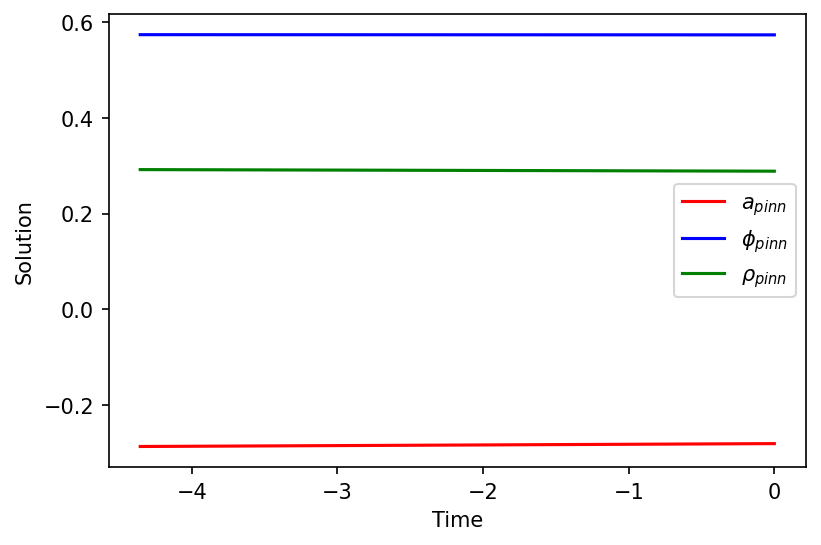

In [64]:
plt.figure(dpi=150)
plt.plot(T, u1_pred, label=r'$a_{pinn}$',color ='r')
plt.plot(T, u2_pred, label=r'$\phi_{pinn}$',color ='b')
plt.plot(T, u3_pred, label=r'$\rho_{pinn}$',color ='g')
# plt.plot(T, u4_pred, label=r'$\rho_{pinn}$',color ='y')
# plt.plot(log10(uuut),log10(uuuy[:,3]),label = r'$a_{numer}$',linestyle='-.')
# plt.plot(log10(uuut),log10(uuuy[:,0]),label = r'$\phi_{numer}$',linestyle='-.')
# plt.plot(log10(uuut),log10(uuuy[:,1]),label = r'$\dot{\phi}_{numer}$',linestyle='-.')
# plt.plot(log10(uuut),log10(uuuy[:,2]),label = r'$\rho_{numer}$',linestyle='-.')
plt.xlabel('Time')
plt.ylabel('Solution')
#plt.ylim(0.9e-8,1.1e-8)
plt.legend()
plt.show()
# print(u1_pred[-1])

In [44]:
1/ln10

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.43429446]], dtype=float32)>

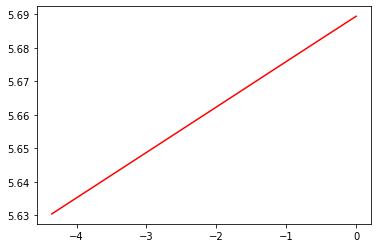

In [60]:
# plt.plot(uuut,uuuy[:,3],label = r'$a$')
plt.plot(T, 10**(tf.reshape(u1_pred,(1000,1))), label=r'$a_{pinn}$',color ='r')


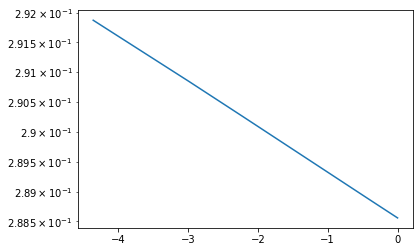

In [68]:
plt.plot(T, (tf.reshape(u3_pred,(1000,1))))
plt.yscale('log')

In [ ]:
plt.plot(uuut,uuuy[:,3],label = r'$a$')
plt.plot(10**T, u3_pred, label=r'$a_{pinn}$',color ='r')

In [22]:
P0

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[nan]], dtype=float32)>

In [24]:
def log10(x):
#     return tf.math.log(x) / tf.math.log(tf.constant([[10.0]], dtype=tf.float32))
    return tf.math.log(x) / tf.math.log(tf.constant([[10.0]]))

In [28]:
P0 = log10(phi_in.astype(np.float32))
P0

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.7456998]], dtype=float32)>

In [23]:
phi_in.astype(np.float32)

-0.3941484

In [35]:
(u1_pred*P0).type

AttributeError: 'tensorflow.python.framework.ops.EagerTensor' object has no attribute 'type'

In [33]:
T.shape

TensorShape([1000, 1])

In [41]:
R0

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[5.2446656]], dtype=float32)>